In [1]:
import jax
import jax.numpy as jnp

import equinox as eqx
import equinox.nn as nn
import snnax.snn as snn

import optax

In [2]:
from eleanor.models import Heracles, Scaler, Bruno
from eleanor.weight_quantization import QuantizedLinear
from chex import Array, PRNGKey
from typing import Optional
import jax.random as jrandom

# key = jax.random.key(13)
# key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)


class EncodingLayer(eqx.Module):
    gain: Array
    bias: Array
    expansion: float

    def __init__(self, gain: Array, bias: Array, expansion: float) -> None:
        self.gain = gain
        self.bias = bias
        self.expansion = expansion

    def __call__(self, synaptic_input: Array, *, key: Optional[PRNGKey] = None):
        output = self.gain * (jnp.tile(synaptic_input, self.expansion) + self.bias)
        return output


def define_model(key):
    alpha = 0.5445472869143363
    beta = 0.8882616429253197
    scaler = 359.1680647317813
    V_thr = 0.34636116263876293

    key1, key2, key3, key4, key5 = jrandom.split(key, 5)
    enc_gain = jax.random.normal(key1, shape=(128,)) * 0.18436009935019085
    enc_bias = jax.random.normal(key2, shape=(128,))
    model = snn.Sequential(
        EncodingLayer(enc_gain, enc_bias, 32),
        QuantizedLinear(128, 256, quant_bits=3, key=key3),
        snn.LIF([alpha, beta], key=key4),
        QuantizedLinear(256, 27, quant_bits=3, key=key5),
        snn.LIF([alpha, beta]),
        # Scaler(scaler),
        # FeLIFV2(dt=1e-3, V_thr=V_thr, paramsScale=1e12),
        # Heracles(dt=1e-3, V_thr=V_thr, paramsScale=1e9),
    )
    return model


# enc_gain = jax.random.normal(key1, shape=(128,)) * 0.18436009935019085
# enc_bias = jax.random.normal(key2, shape=(128,))
# model = snn.Sequential(
#     EncodingLayer(enc_gain, enc_bias, 32),
#     # nn.Linear(128, 256, key=key3),
#     QLinear(128, 256, n_bits=2, key=key3),
#     snn.LIF([0.5445472869143363, 0.8882616429253197], key=key4),
#     # Scaler(100),
#     # Heracles(dt=1e-3, V_thr=0.3, paramsScale=1e12),
#     # nn.Linear(256, 27, key=key5),
#     QLinear(256, 27, n_bits=2, key=key5),
#     # snn.LIF([.9, .8], key=key6)
#     Scaler(359.1680647317813),
#     Heracles(dt=1e-3, V_thr=0.34636116263876293, paramsScale=1e12),
#     # FeLIFV2(dt=1e-3, V_thr=0.3, paramsScale=1e12),
# )
# model

In [3]:
# qval = model[1].quantizer.quant(model[1].weight, calibration_axes=(0, 1))
# jnp.unique(qval[0].qvalue.astype(int))

In [4]:
from functools import partial
from jax.tree_util import tree_map


# Simple batched loss function
@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def loss_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)

    # Get the output of last layer
    # final_layer_out = out_spikes[-1][0]
    final_layer_out = out_spikes[-1]

    # Sum all spikes in each output neuron along time axis
    # pred = tree_map(lambda x: jnp.sum(x, axis=0), final_layer_out)
    pred = final_layer_out.sum(axis=0)

    target = jax.nn.one_hot(tgt_class, 27)
    loss = optax.softmax_cross_entropy(pred, target)
    return loss


# Calculating the gradient with Equinox PyTree filters and
# subsequently jitting the resulting function
@eqx.filter_value_and_grad
def loss_and_grad(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    return jnp.mean(loss_fn(model, in_states, in_spikes, tgt_class, keys))


@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def accuracy_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)
    # final_layer_out = out_spikes[-1][0]
    final_layer_out = out_spikes[-1]
    pred = final_layer_out.sum(axis=0)
    predicted_class = jnp.argmax(pred)
    return predicted_class == tgt_class


@eqx.filter_jit
def calc_accuracy(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    accuracy = accuracy_fn(model, in_states, in_spikes, tgt_class, keys)
    return jnp.mean(accuracy)


# Finally, we update the parameters using a simple optimizer
@eqx.filter_jit
def update(model, optim, in_states, opt_state, in_spikes, tgt_class, key):
    # Get gradients
    loss, grads = loss_and_grad(model, in_states, in_spikes, tgt_class, key)

    # Calculate parameter updates using the optimizer
    updates, opt_state = optim.update(grads, opt_state)

    # Update parameter PyTree with Equinox and optax
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [5]:
from eleanor.datasets import shuffle, loadBraille

trainset, testset, nb_outputs, nb_channels, nb_steps, time_step = loadBraille(2, 200)
print(nb_channels)
print(nb_steps)
print(time_step)

4
102
0.001


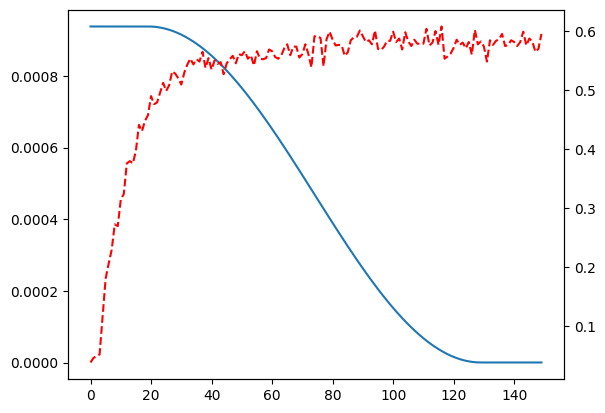

100%|██████████| 150/150 [02:37<00:00,  1.05s/it]


In [6]:
import matplotlib.pyplot as plt
from tqdm import trange
from IPython.display import clear_output

key = jrandom.key(13)
key, kmodel = jrandom.split(key, 2)

model = define_model(kmodel)

learning_rate = 0.0009379401221926483
epochs = 150

# optim = optax.adamax(learning_rate=0.0009379401221926483, b1=0.9, b2=0.995)
# scheduler = optax.schedules.exponential_decay(learning_rate, transition_begin=20*33, transition_steps=33, decay_rate=0.99, staircase=True)
scheduler = optax.warmup_cosine_decay_schedule(
    init_value=learning_rate,
    peak_value=learning_rate,
    warmup_steps=20 * 33,
    decay_steps=int(epochs - 20) * 33,
    end_value=2e-4 * learning_rate,
)

optim = optax.inject_hyperparams(optax.adamax)(
    learning_rate=scheduler, b1=0.9, b2=0.995
)
# optim = optax.adamax(learning_rate=scheduler, b1=0.9, b2=0.995)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

initial_state = model.init_state(in_shape=(4,), key=jax.random.key(0))
total_loss = []
total_accuracy = []
total_lr = []

pbar = trange(0, epochs)
for epoch in pbar:
    key, epoch_key, train_key, test_key = jax.random.split(key, 4)
    x_train, y_train = shuffle(trainset, epoch_key, 128)
    loss_train = []
    for in_spikes, tgt_class in zip(x_train, y_train):
        # Initializing the membrane potentials of LIF neurons
        model, opt_state, loss = update(
            model, optim, initial_state, opt_state, in_spikes, tgt_class, train_key
        )
        loss_train.append(loss)

    loss_train = jnp.mean(jnp.asarray(loss_train))
    total_loss.append(loss_train)

    x_test, y_test = shuffle(testset, jax.random.key(0), 128)
    accuracy_test = []
    for in_spikes, tgt_class in zip(x_test, y_test):
        # Initializing the membrane potentials of LIF neurons
        accuracy = calc_accuracy(model, initial_state, in_spikes, tgt_class, test_key)
        accuracy_test.append(accuracy)
    accuracy_test = jnp.mean(jnp.asarray(accuracy_test))
    total_accuracy.append(accuracy_test)
    total_lr.append(opt_state.hyperparams["learning_rate"])

    clear_output(wait=True)
    fig, axs = plt.subplots()
    axs.plot(total_lr)
    axs.twinx().plot(total_accuracy, "r--")

    plt.show()
    plt.close()

In [24]:
# jnp.save("results/brailleLossFeLIF_Bruno.npy", total_loss)
# jnp.save("results/brailleAccFeLIF_Bruno.npy", total_accuracy)

jnp.save("results2/brailleLossHeracles2Bit.npy", total_loss)
jnp.save("results2/brailleAccHeracles2Bit.npy", total_accuracy)

# jnp.save("results2/brailleLossLIF2Bit.npy", total_loss)
# jnp.save("results2/brailleAccLIF2Bit.npy", total_accuracy)